Step 1: Load Dataset


In [1]:
import pandas as pd
df=pd.read_csv("train.csv")
df.head()

,UniqueID,disbursed_amount,asset_cost,ltv,branch_id,supplier_id,manufacturer_id,Current_pincode_ID,Date.of.Birth,Employment.Type,...,SEC.SANCTIONED.AMOUNT,SEC.DISBURSED.AMOUNT,PRIMARY.INSTAL.AMT,SEC.INSTAL.AMT,NEW.ACCTS.IN.LAST.SIX.MONTHS,DELINQUENT.ACCTS.IN.LAST.SIX.MONTHS,AVERAGE.ACCT.AGE,CREDIT.HISTORY.LENGTH,NO.OF_INQUIRIES,loan_default
0,420825,50578,58400,89.55,67,22807,45,1441,01-01-84,Salaried,...,0.0,0.0,0.0,0.0,0.0,0.0,0yrs 0mon,0yrs 0mon,0.0,0.0
1,537409,47145,65550,73.23,67,22807,45,1502,31-07-85,Self employed,...,0.0,0.0,1991.0,0.0,0.0,1.0,1yrs 11mon,1yrs 11mon,0.0,1.0
2,417566,53278,61360,89.63,67,22807,45,1497,24-08-85,Self employed,...,0.0,0.0,0.0,0.0,0.0,0.0,0yrs 0mon,0yrs 0mon,0.0,0.0
3,624493,57513,66113,88.48,67,22807,45,1501,30-12-93,Self employed,...,0.0,0.0,31.0,0.0,0.0,0.0,0yrs 8mon,1yrs 3mon,1.0,1.0
4,539055,52378,60300,88.39,67,22807,45,1495,09-12-77,Self employed,...,0.0,0.0,0.0,0.0,0.0,0.0,0yrs 0mon,0yrs 0mon,1.0,1.0


In [2]:
print(df['Date.of.Birth'].head())

0    01-01-84
1    31-07-85
2    24-08-85
3    30-12-93
4    09-12-77
Name: Date.of.Birth, dtype: object


In [3]:
print(df['Date.of.Birth'].iloc[0:10].to_string())
print(df['DisbursalDate'].iloc[0:10].to_string())

0    01-01-84
1    31-07-85
2    24-08-85
3    30-12-93
4    09-12-77
5    08-09-90
6    01-06-88
7    04-10-89
8    15-11-91
9    01-06-68
0    03-08-18
1    26-09-18
2    01-08-18
3    26-10-18
4    26-09-18
5    19-09-18
6    23-09-18
7    16-09-18
8    05-09-18
9    16-09-18


In [4]:
df.shape

(41016, 41)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41016 entries, 0 to 41015
Data columns (total 41 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   UniqueID                             41016 non-null  int64  
 1   disbursed_amount                     41016 non-null  int64  
 2   asset_cost                           41016 non-null  int64  
 3   ltv                                  41016 non-null  float64
 4   branch_id                            41016 non-null  int64  
 5   supplier_id                          41016 non-null  int64  
 6   manufacturer_id                      41016 non-null  int64  
 7   Current_pincode_ID                   41016 non-null  int64  
 8   Date.of.Birth                        41016 non-null  object 
 9   Employment.Type                      39429 non-null  object 
 10  DisbursalDate                        41016 non-null  object 
 11  State_ID                    

In [6]:
df.isnull().sum()

,0
UniqueID,0
disbursed_amount,0
asset_cost,0
ltv,0
branch_id,0
supplier_id,0
manufacturer_id,0
Current_pincode_ID,0
Date.of.Birth,0
Employment.Type,1587


In [7]:
df['loan_default'].value_counts()

,count
loan_default,
0.0,32776
1.0,8239


Step 2: Clean missing values

In [8]:
df['Employment.Type'] = df['Employment.Type'].fillna('Unknown')

In [9]:
numeric_cols = df.select_dtypes(include='number').columns.drop('loan_default')

for col in numeric_cols:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].median())

In [10]:
df = df.dropna(subset=['loan_default'])

In [11]:
df.isnull().sum().sum()

np.int64(0)

In [12]:
def convert_to_months(x):
    if pd.isna(x):
        return None

    parts = x.split()
    years = int(parts[0].replace('yrs', ''))
    months = int(parts[1].replace('mon', ''))

    return years * 12 + months

In [13]:
df['average_acct_age_months'] = df['AVERAGE.ACCT.AGE'].apply(convert_to_months)

df['credit_history_months'] = df['CREDIT.HISTORY.LENGTH'].apply(convert_to_months)

In [14]:
df['average_acct_age_months'] = df['average_acct_age_months'].fillna(
    df['average_acct_age_months'].median()
)

df['credit_history_months'] = df['credit_history_months'].fillna(
    df['credit_history_months'].median()
)

In [15]:
df.drop(columns=['AVERAGE.ACCT.AGE', 'CREDIT.HISTORY.LENGTH'], inplace=True)

In [16]:
df.isnull().sum().sum()

np.int64(0)

Step 3: Check for duplicate records

In [17]:
df.duplicated().sum()

np.int64(0)

In [18]:
df['UniqueID'].duplicated().sum()

np.int64(0)

In [19]:
df['UniqueID'].is_unique

True

Step 4: Understand the target

In [20]:
df['loan_default'].value_counts(normalize=True).mul(100).round(2)

,proportion
loan_default,
0.0,79.91
1.0,20.09


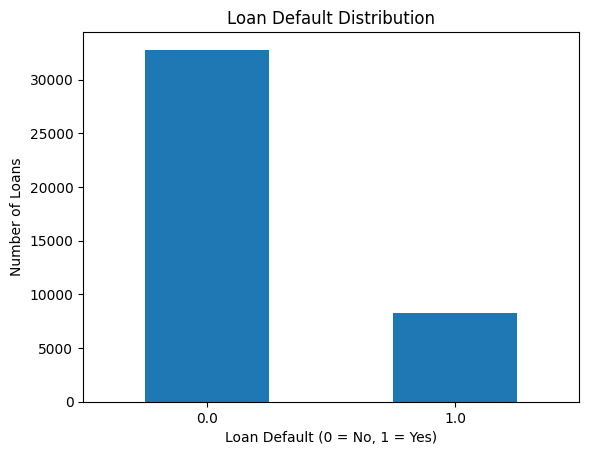

In [21]:
import matplotlib.pyplot as plt

df['loan_default'].value_counts().sort_index().plot(kind='bar')

plt.title('Loan Default Distribution')
plt.xlabel('Loan Default (0 = No, 1 = Yes)')
plt.ylabel('Number of Loans')
plt.xticks(rotation=0)
plt.show()

Step 5: Compare default rates by LTV

In [22]:
df['ltv_bucket'] = pd.cut(
    df['ltv'],
    bins=[0, 60, 70, 80, 90, 100, float('inf')],
    labels=['<60', '60–70', '70–80', '80–90', '90–100', '100+']
)

In [23]:
ltv_default = (
    df.groupby('ltv_bucket', observed=True)['loan_default']
      .mean()
      .mul(100)
      .round(2)
)

print(ltv_default)

ltv_bucket
<60       13.33
60–70     17.05
70–80     20.14
80–90     24.44
90–100    17.99
Name: loan_default, dtype: float64


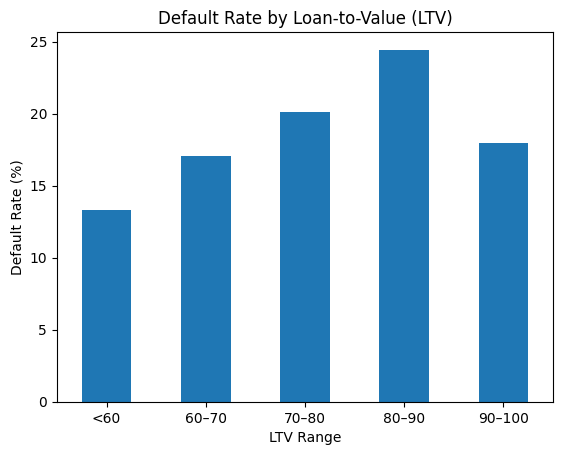

In [24]:
ltv_default.plot(kind='bar')

plt.title('Default Rate by Loan-to-Value (LTV)')
plt.xlabel('LTV Range')
plt.ylabel('Default Rate (%)')
plt.xticks(rotation=0)
plt.show()

Step 6: Credit score vs default

In [25]:
df['PERFORM_CNS.SCORE'].describe()

,PERFORM_CNS.SCORE
count,41015.000000
mean,292.929587
std,342.696664
min,0.000000
25%,0.000000
50%,0.000000
75%,687.000000
max,890.000000


In [26]:
df['credit_score_bucket'] = pd.cut(
    df['PERFORM_CNS.SCORE'],
    bins=[-1, 0, 300, 600, 750, 900, float('inf')],
    labels=['No Score', '1–300', '301–600', '601–750', '751–900', '900+']
)

In [27]:
credit_default = (
    df.groupby('credit_score_bucket', observed=True)['loan_default']
      .mean()
      .mul(100)
      .round(2)
)

print(credit_default)

credit_score_bucket
No Score    21.51
1–300       23.18
301–600     26.14
601–750     17.20
751–900     13.39
Name: loan_default, dtype: float64


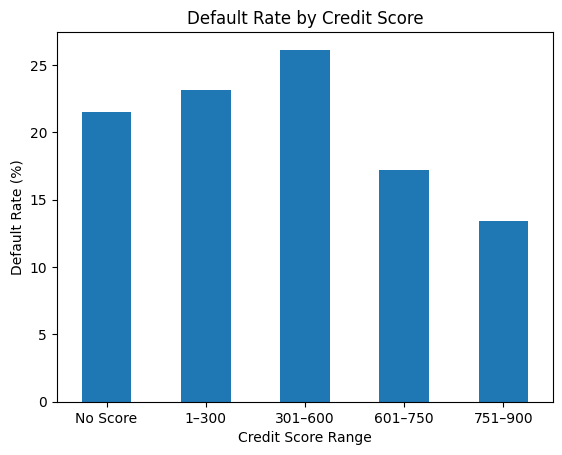

In [28]:
credit_default.plot(kind='bar')

plt.title('Default Rate by Credit Score')
plt.xlabel('Credit Score Range')
plt.ylabel('Default Rate (%)')
plt.xticks(rotation=0)
plt.show()

Step 12: Overdue Accounts vs Default.

In [41]:
overdue_default = (
    df.groupby(
        pd.cut(
            df['PRI.OVERDUE.ACCTS'],
            bins=[-1, 0, 1, 2, 3, 5, float('inf')],
            labels=['0', '1', '2', '3', '4–5', '6+']
        ),
        observed=True
    )['loan_default']
    .mean()
    .mul(100)
    .round(2)
)

print(overdue_default)

PRI.OVERDUE.ACCTS
0      19.47
1      25.22
2      26.47
3      28.42
4–5    25.29
6+     23.53
Name: loan_default, dtype: float64


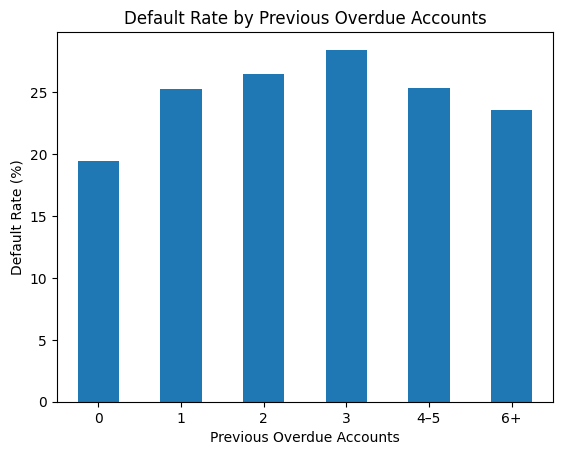

In [42]:
overdue_default.plot(kind='bar')
plt.title('Default Rate by Previous Overdue Accounts')
plt.xlabel('Previous Overdue Accounts')
plt.ylabel('Default Rate (%)')
plt.xticks(rotation=0)
plt.show()

Step : Correlation Analysis

In [43]:
corr = df.select_dtypes(include='number').corr()['loan_default'].sort_values()

print(corr)

PERFORM_CNS.SCORE                     -0.058149
credit_history_months                 -0.040753
Aadhar_flag                           -0.038058
PRI.ACTIVE.ACCTS                      -0.036264
manufacturer_id                       -0.032256
PRI.SANCTIONED.AMOUNT                 -0.030647
PRI.DISBURSED.AMOUNT                  -0.030165
average_acct_age_months               -0.027464
PRI.CURRENT.BALANCE                   -0.026812
PRI.NO.OF.ACCTS                       -0.026689
NEW.ACCTS.IN.LAST.SIX.MONTHS          -0.018917
PAN_flag                              -0.018705
Passport_flag                         -0.011304
Driving_flag                          -0.009786
Employee_code_ID                      -0.008445
SEC.SANCTIONED.AMOUNT                 -0.007734
SEC.DISBURSED.AMOUNT                  -0.007705
SEC.CURRENT.BALANCE                   -0.006492
PRIMARY.INSTAL.AMT                    -0.005445
SEC.NO.OF.ACCTS                       -0.004542
SEC.ACTIVE.ACCTS                      -0

In [44]:
df['loan_asset_gap'] = df['asset_cost'] - df['disbursed_amount']

In [45]:
df['credit_history_years'] = df['credit_history_months'] / 12

In [46]:
df['average_account_age_years'] = df['average_acct_age_months'] / 12

In [47]:
X = df.drop(columns=['loan_default'])
y = df['loan_default']

In [48]:
categorical_cols = X.select_dtypes(include='object').columns
print(categorical_cols)

Index(['Date.of.Birth', 'Employment.Type', 'DisbursalDate',
       'PERFORM_CNS.SCORE.DESCRIPTION'],
      dtype='object')


Step : Train test split

In [51]:
X = df.drop(columns=['loan_default'])
y = df['loan_default']

X = X.drop(columns=['Date.of.Birth', 'DisbursalDate'])

X = pd.get_dummies(X, drop_first=True)

X = X.apply(pd.to_numeric, errors='coerce')

X = X.fillna(0)

# Train-test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

Step : Model training

In [54]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LogisticRegression(
    max_iter=1000,
    class_weight='balanced'
)

model.fit(X_train_scaled, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

In [55]:
y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))
print(classification_report(y_test, y_pred))

Accuracy: 0.5799097891015482
ROC-AUC: 0.6273032332837157
              precision    recall  f1-score   support

         0.0       0.85      0.57      0.68      6555
         1.0       0.26      0.61      0.37      1648

    accuracy                           0.58      8203
   macro avg       0.56      0.59      0.53      8203
weighted avg       0.74      0.58      0.62      8203



In [58]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_scaled,
    y_train
)

In [59]:
smote_model = LogisticRegression(max_iter=1000)

smote_model.fit(X_train_smote, y_train_smote)

LogisticRegression(max_iter=1000)

In [60]:
smote_pred = smote_model.predict(X_test_scaled)
smote_prob = smote_model.predict_proba(X_test_scaled)[:, 1]

print("Accuracy:", accuracy_score(y_test, smote_pred))
print("ROC-AUC:", roc_auc_score(y_test, smote_prob))
print(classification_report(y_test, smote_pred))

Accuracy: 0.5728392051688407
ROC-AUC: 0.6237508609006688
              precision    recall  f1-score   support

         0.0       0.85      0.56      0.68      6555
         1.0       0.26      0.60      0.36      1648

    accuracy                           0.57      8203
   macro avg       0.55      0.58      0.52      8203
weighted avg       0.73      0.57      0.62      8203



Feature Importance

In [61]:
feature_importance = pd.Series(
    model.coef_[0],
    index=X.columns
).sort_values()

print(feature_importance.head(10))
print(feature_importance.tail(10))

PERFORM_CNS.SCORE                                           -0.677106
age                                                         -0.459737
PERFORM_CNS.SCORE.DESCRIPTION_No Bureau History Available   -0.386224
loan_amount_bucket_50–75K                                   -0.270679
loan_amount_bucket_30–50K                                   -0.270269
PRI.DISBURSED.AMOUNT                                        -0.181803
PRI.ACTIVE.ACCTS                                            -0.147405
loan_amount_bucket_75–100K                                  -0.115657
PERFORM_CNS.SCORE.DESCRIPTION_D-Very Low Risk               -0.107259
manufacturer_id                                             -0.099342
dtype: float64
NO.OF_INQUIRIES                  0.110559
Employment.Type_Self employed    0.119137
State_ID                         0.162051
credit_score_bucket_751–900      0.167532
ltv                              0.315466
credit_score_bucket_601–750      0.326428
age_group_26–30                  

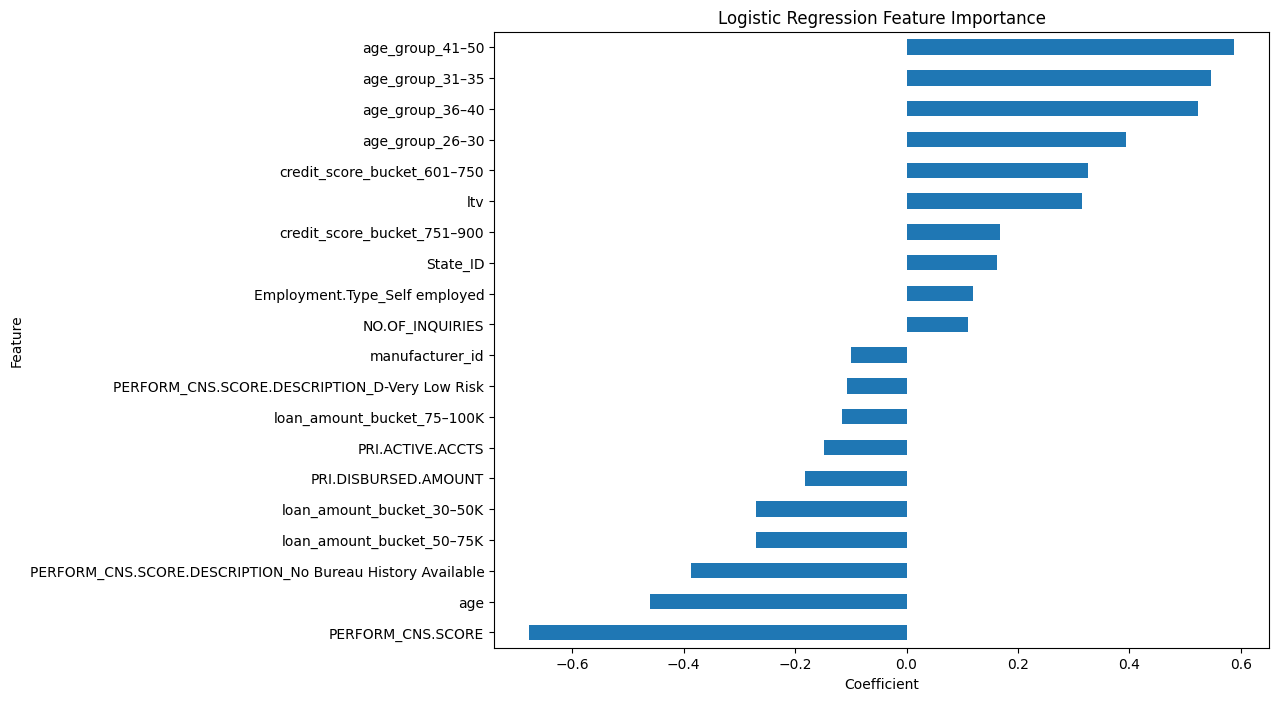

In [62]:
top_features = pd.concat([
    feature_importance.head(10),
    feature_importance.tail(10)
])

top_features.plot(kind='barh', figsize=(10, 8))
plt.title('Logistic Regression Feature Importance')
plt.xlabel('Coefficient')
plt.ylabel('Feature')
plt.show()

In [63]:
df.to_csv("loan_risk_cleaned.csv", index=False)

In [65]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    random_state=42
)

xgb_model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None,
              num_parallel_tree=None, ...)

In [66]:
xgb_pred = xgb_model.predict(X_test)
xgb_prob = xgb_model.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, xgb_pred))
print("ROC-AUC:", roc_auc_score(y_test, xgb_prob))
print(classification_report(y_test, xgb_pred))

Accuracy: 0.7994636108740705
ROC-AUC: 0.6524488921226663
              precision    recall  f1-score   support

         0.0       0.80      1.00      0.89      6555
         1.0       0.52      0.02      0.04      1648

    accuracy                           0.80      8203
   macro avg       0.66      0.51      0.46      8203
weighted avg       0.75      0.80      0.72      8203



In [69]:
from sklearn.metrics import precision_score, recall_score

In [70]:
for t in [0.20, 0.25, 0.30, 0.35, 0.40]:
    pred = (xgb_prob >= t).astype(int)

    print(
        t,
        "Precision:", round(precision_score(y_test, pred), 2),
        "Recall:", round(recall_score(y_test, pred), 2)
    )

0.2 Precision: 0.28 Recall: 0.62
0.25 Precision: 0.31 Recall: 0.44
0.3 Precision: 0.34 Recall: 0.29
0.35 Precision: 0.37 Recall: 0.16
0.4 Precision: 0.41 Recall: 0.09


In [71]:
for t in [0.05, 0.10, 0.15, 0.20]:
    pred = (xgb_prob >= t).astype(int)

    print(
        t,
        "Precision:", round(precision_score(y_test, pred), 2),
        "Recall:", round(recall_score(y_test, pred), 2)
    )

0.05 Precision: 0.2 Recall: 1.0
0.1 Precision: 0.23 Recall: 0.93
0.15 Precision: 0.25 Recall: 0.78
0.2 Precision: 0.28 Recall: 0.62


In [72]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

xgb_cv = cross_val_score(
    xgb_model,
    X,
    y,
    cv=cv,
    scoring='roc_auc'
)

log_cv = cross_val_score(
    model,
    X_train_scaled,
    y_train,
    cv=5,
    scoring='roc_auc'
)

print("XGBoost CV AUC:", xgb_cv)
print("XGBoost Mean AUC:", xgb_cv.mean())

print("Logistic CV AUC:", log_cv)
print("Logistic Mean AUC:", log_cv.mean())

XGBoost CV AUC: [0.67478647 0.6711303  0.66995086 0.66018529 0.66262469]
XGBoost Mean AUC: 0.667735523020536
Logistic CV AUC: [0.64342918 0.64452735 0.64554519 0.64627267 0.64132605]
Logistic Mean AUC: 0.6442200887697855


In [73]:
decile_df = pd.DataFrame({
    'actual': y_test.values,
    'probability': xgb_prob
})

decile_df['decile'] = pd.qcut(
    decile_df['probability'],
    10,
    labels=False,
    duplicates='drop'
)

decile_analysis = (
    decile_df.groupby('decile')
    .agg(
        loans=('actual', 'count'),
        defaults=('actual', 'sum'),
        default_rate=('actual', 'mean'),
        avg_probability=('probability', 'mean')
    )
    .sort_index(ascending=False)
)

decile_analysis['default_rate'] *= 100

print(decile_analysis)

        loans  defaults  default_rate  avg_probability
decile                                                
9         821     298.0     36.297199         0.406156
8         820     239.0     29.146341         0.310397
7         820     223.0     27.195122         0.264288
6         820     186.0     22.682927         0.228008
5         820     165.0     20.121951         0.196894
4         821     151.0     18.392205         0.168172
3         820     122.0     14.878049         0.142156
2         820     120.0     14.634146         0.117917
1         820      80.0      9.756098         0.093341
0         821      64.0      7.795371         0.060217


KS statistic + lift

In [74]:
overall_default_rate = decile_df['actual'].mean()

decile_analysis['lift'] = (
    decile_analysis['default_rate'] / (overall_default_rate * 100)
)

print(decile_analysis)

        loans  defaults  default_rate  avg_probability      lift
decile                                                          
9         821     298.0     36.297199         0.406156  1.806711
8         820     239.0     29.146341         0.310397  1.450773
7         820     223.0     27.195122         0.264288  1.353650
6         820     186.0     22.682927         0.228008  1.129054
5         820     165.0     20.121951         0.196894  1.001580
4         821     151.0     18.392205         0.168172  0.915481
3         820     122.0     14.878049         0.142156  0.740562
2         820     120.0     14.634146         0.117917  0.728422
1         820      80.0      9.756098         0.093341  0.485614
0         821      64.0      7.795371         0.060217  0.388018


In [75]:
decile_analysis['cum_defaults'] = (
    decile_analysis['defaults'].cumsum() /
    decile_analysis['defaults'].sum()
)

decile_analysis['cum_loans'] = (
    decile_analysis['loans'].cumsum() /
    decile_analysis['loans'].sum()
)

decile_analysis['ks'] = (
    (decile_analysis['cum_defaults'] -
     decile_analysis['cum_loans']).abs()
)

print("Maximum KS:", decile_analysis['ks'].max())

Maximum KS: 0.1742114387466579


decile/lift chart

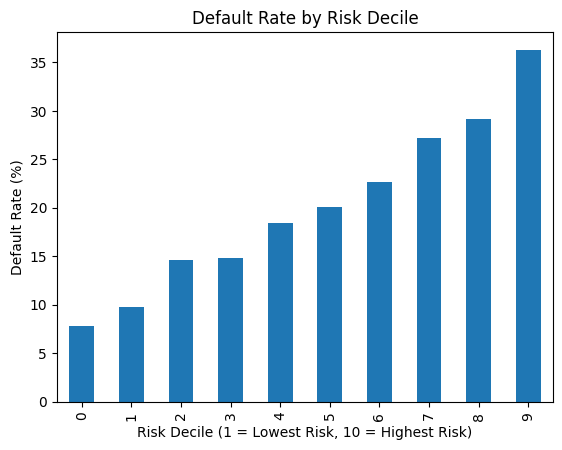

In [76]:
decile_analysis.sort_index(ascending=True)['default_rate'].plot(
    kind='bar'
)

plt.title('Default Rate by Risk Decile')
plt.xlabel('Risk Decile (1 = Lowest Risk, 10 = Highest Risk)')
plt.ylabel('Default Rate (%)')
plt.show()

In [77]:
print(df.columns.tolist())

['UniqueID', 'disbursed_amount', 'asset_cost', 'ltv', 'branch_id', 'supplier_id', 'manufacturer_id', 'Current_pincode_ID', 'Date.of.Birth', 'Employment.Type', 'DisbursalDate', 'State_ID', 'Employee_code_ID', 'MobileNo_Avl_Flag', 'Aadhar_flag', 'PAN_flag', 'VoterID_flag', 'Driving_flag', 'Passport_flag', 'PERFORM_CNS.SCORE', 'PERFORM_CNS.SCORE.DESCRIPTION', 'PRI.NO.OF.ACCTS', 'PRI.ACTIVE.ACCTS', 'PRI.OVERDUE.ACCTS', 'PRI.CURRENT.BALANCE', 'PRI.SANCTIONED.AMOUNT', 'PRI.DISBURSED.AMOUNT', 'SEC.NO.OF.ACCTS', 'SEC.ACTIVE.ACCTS', 'SEC.OVERDUE.ACCTS', 'SEC.CURRENT.BALANCE', 'SEC.SANCTIONED.AMOUNT', 'SEC.DISBURSED.AMOUNT', 'PRIMARY.INSTAL.AMT', 'SEC.INSTAL.AMT', 'NEW.ACCTS.IN.LAST.SIX.MONTHS', 'DELINQUENT.ACCTS.IN.LAST.SIX.MONTHS', 'NO.OF_INQUIRIES', 'loan_default', 'average_acct_age_months', 'credit_history_months', 'ltv_bucket', 'credit_score_bucket', 'age', 'age_group', 'loan_amount_bucket', 'loan_asset_gap', 'credit_history_years', 'average_account_age_years']


In [78]:
df.to_csv("loan_risk_cleaned.csv", index=False)

In [80]:
# Prepare risk decile results in ascending order for Power BI
decile_analysis.sort_index(ascending=True)[['default_rate']]

,default_rate
decile,
0,7.795371
1,9.756098
2,14.634146
3,14.878049
4,18.392205
5,20.121951
6,22.682927
7,27.195122
8,29.146341
